# Whisper vs WhisperX — Bilingual ASR Demo

**Branch:** `feature/whisperx-baseline-demo`  
**Task:** Compare Whisper and WhisperX on 50 bilingual (es→en) utterances using pre-computed results.  
**No model inference required** — all results are loaded from `results/`.

---

| Config | Backend | Model | Device |
|--------|---------|-------|--------|
| Whisper base CPU | Whisper | base | CPU |
| Whisper large-v3 CPU | Whisper | large-v3 | CPU |
| WhisperX base CPU | WhisperX | base | CPU |
| WhisperX large-v3 CPU | WhisperX | large-v3 | CPU |

## 0. Setup

In [9]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from IPython.display import display

# Resolve repo root relative to this notebook
ROOT = Path(globals().get('__vsc_ipynb_file__', __file__ if '__file__' in dir() else 'notebooks/x')).resolve().parent.parent
# Fallback: walk up from cwd
if not (ROOT / 'results').exists():
    ROOT = Path.cwd()
    while ROOT != ROOT.parent:
        if (ROOT / 'results').exists():
            break
        ROOT = ROOT.parent

print('ROOT:', ROOT)
assert (ROOT / 'results').exists(), f'results/ not found under {ROOT}'

ROOT: F:\EE519\Team proj\SwitchNet


## 1. Summary Comparison

Load pre-computed WER/MER summaries for all four configurations on the **50-utterance bilingual es→en** test set.

In [10]:
configs = [
    ('Whisper',  'base',     'CPU', 'results/bilingual_es-en_50_base_cpu_summary.json'),
    ('Whisper',  'large-v3', 'CPU', 'results/bilingual_es-en_50_large_cpu_summary.json'),
    ('WhisperX', 'base',     'CPU', 'results/wx_bilingual_es-en_50_base_cpu_summary.json'),
    ('WhisperX', 'large-v3', 'CPU', 'results/wx_bilingual_es-en_50_large_cpu_summary.json'),
]

rows = []
per_entry = {}
for backend, model, device, rel_path in configs:
    path = ROOT / rel_path
    with open(path) as f:
        data = json.load(f)
    ov = data['overall']
    rows.append({
        'Backend':  backend,
        'Model':    model,
        'Device':   device,
        'N':        ov['n_utterances'],
        'WER':      round(ov['wer'], 4),
        'MER':      round(ov['mer'], 4),
    })
    per_entry[f'{backend}_{model}'] = data['per_entry']

summary_df = pd.DataFrame(rows)
summary_df.style.highlight_min(subset=['WER', 'MER'], color='#c6efce')

,Backend,Model,Device,N,WER,MER
0,Whisper,base,CPU,50,0.110500,0.108300
1,Whisper,large-v3,CPU,50,0.054000,0.052800
2,WhisperX,base,CPU,50,0.098300,0.096600
3,WhisperX,large-v3,CPU,50,0.035600,0.035400


## 2. WER Comparison — Bar Chart

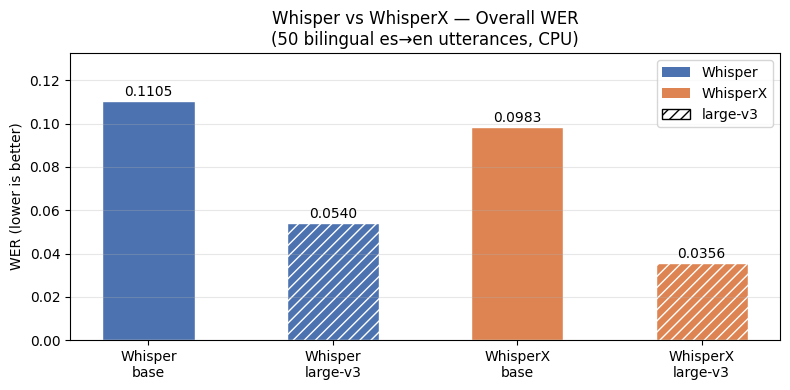

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

labels = [f"{r['Backend']}\n{r['Model']}" for _, r in summary_df.iterrows()]
wers   = summary_df['WER'].tolist()
colors = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452']  # blue=Whisper, orange=WhisperX
hatches = ['', '///', '', '///']

bars = ax.bar(labels, wers, color=colors, hatch=hatches, edgecolor='white', width=0.5)

for bar, val in zip(bars, wers):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('WER (lower is better)')
ax.set_title('Whisper vs WhisperX — Overall WER\n(50 bilingual es→en utterances, CPU)')
ax.set_ylim(0, max(wers) * 1.2)
ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='Whisper'),
    Patch(facecolor='#DD8452', label='WhisperX'),
    Patch(facecolor='white', hatch='///', edgecolor='black', label='large-v3'),
]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

## 3. Per-entry WER Scatter — large-v3 CPU

Each point is one bilingual utterance. Points **below the diagonal** = WhisperX improves over Whisper; **above** = Whisper wins.

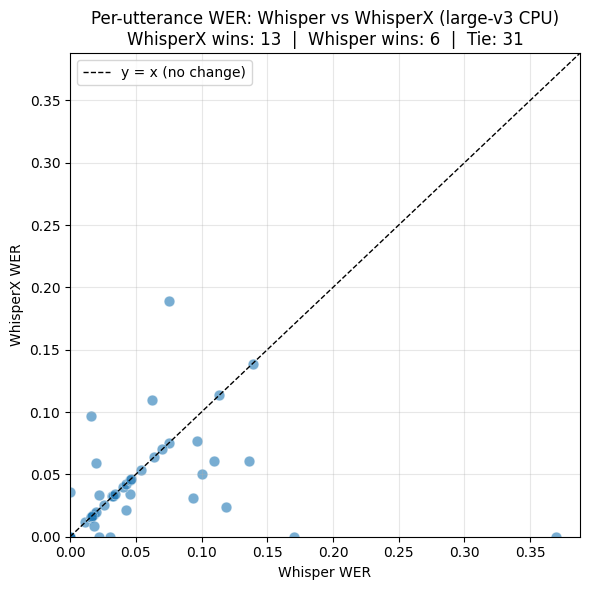

In [12]:
w_entries  = per_entry['Whisper_large-v3']
wx_entries = per_entry['WhisperX_large-v3']

w_wers  = [e['wer'] for e in w_entries]
wx_wers = [e['wer'] for e in wx_entries]

n_wx_wins   = sum(wx < w  for wx, w in zip(wx_wers, w_wers))
n_whisper_wins = sum(w < wx for wx, w in zip(wx_wers, w_wers))
n_tie       = sum(wx == w  for wx, w in zip(wx_wers, w_wers))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(w_wers, wx_wers, alpha=0.6, edgecolors='white', linewidths=0.5, s=60)

lim = max(max(w_wers), max(wx_wers)) * 1.05
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='y = x (no change)')

ax.set_xlabel('Whisper WER')
ax.set_ylabel('WhisperX WER')
ax.set_title('Per-utterance WER: Whisper vs WhisperX (large-v3 CPU)\n'
             f'WhisperX wins: {n_wx_wins}  |  Whisper wins: {n_whisper_wins}  |  Tie: {n_tie}')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Qualitative Examples

Three utterances with the **largest WER difference** between Whisper and WhisperX (large-v3 CPU).  
Reference text is the ground-truth bilingual transcript (Spanish + English concatenated).

In [ ]:
# Compute per-entry WER diff and pick top 3 most-changed
diffs = []
for we, wxe in zip(w_entries, wx_entries):
    diffs.append({
        'id':         we['id'],
        'Whisper WER':   we['wer'],
        'WhisperX WER':  wxe['wer'],
        'delta (WX−W)':  round(wxe['wer'] - we['wer'], 4),
        'W subs/del/ins':  f"{we['substitutions']}/{we['deletions']}/{we['insertions']}",
        'WX subs/del/ins': f"{wxe['substitutions']}/{wxe['deletions']}/{wxe['insertions']}",
        'ref_words':  we['ref_words'],
    })

diffs.sort(key=lambda x: abs(x['delta (WX−W)']), reverse=True)
top3 = diffs[:3]

# Belt-and-suspenders: fix residual mojibake in displayed reference text
def fix_mojibake(s):
    try:
        return s.encode('latin-1').decode('utf-8')
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s

# Load reference transcripts and audio paths — UTF-8 required for Spanish characters
manifest_path = ROOT / 'data' / 'manifests' / 'bilingual_es-en_50.jsonl'
ref_map = {}
seg_audio_map = {}  # id -> {'es': Path, 'en': Path}
with open(manifest_path, encoding='utf-8') as f:
    for line in f:
        e = json.loads(line)
        ref_map[e['id']] = e.get('transcript', '')
        paths = {}
        for seg in e.get('segments', []):
            lang = seg.get('language', '')
            ap   = seg.get('audio_path', '')
            if lang in ('es', 'en') and ap:
                paths[lang] = Path(ap)
        seg_audio_map[e['id']] = paths

print(f"{'='*80}")
for i, d in enumerate(top3, 1):
    ref = fix_mojibake(ref_map.get(d['id'], '(not found)'))
    delta = d['delta (WX−W)']
    direction = '✓ WhisperX better' if delta < 0 else '✗ Whisper better'
    print(f"Example {i}: {direction}  (ΔWER = {delta:+.4f})")
    print(f"  ID: {d['id']}")
    print(f"  REF ({d['ref_words']} words):")
    # wrap ref at ~100 chars
    words = ref.split()
    line_buf = '    '
    for w in words:
        if len(line_buf) + len(w) + 1 > 100:
            print(line_buf)
            line_buf = '    ' + w
        else:
            line_buf += (' ' if line_buf.strip() else '') + w
    if line_buf.strip():
        print(line_buf)
    print(f"  Whisper  WER={d['Whisper WER']:.4f}  subs/del/ins={d['W subs/del/ins']}")
    print(f"  WhisperX WER={d['WhisperX WER']:.4f}  subs/del/ins={d['WX subs/del/ins']}")
    print(f"{'='*80}")

In [ ]:
from IPython.display import Audio, display as ipy_display

_LANG_LABEL = {'es': 'Spanish (ES)', 'en': 'English (EN)'}

for i, d in enumerate(top3, 1):
    delta  = d['delta (WX−W)']
    winner = '✓ WhisperX better' if delta < 0 else '✗ Whisper better'
    ref    = fix_mojibake(ref_map.get(d['id'], ''))
    segs   = seg_audio_map.get(d['id'], {})

    # ── header ────────────────────────────────────────────────────────────────
    print(f"\n{'─'*72}")
    print(f"Example {i}: {winner}   ΔWER = {delta:+.4f}"
          f"   (Whisper {d['Whisper WER']:.4f} → WhisperX {d['WhisperX WER']:.4f})")

    # ── audio playback: Spanish segment then English segment ──────────────────
    for lang in ('es', 'en'):
        ap = segs.get(lang)
        if ap and ap.exists():
            print(f"  ▶ {_LANG_LABEL[lang]}")
            ipy_display(Audio(filename=str(ap)))
        elif ap:
            print(f"  Audio not found: {ap}")

    # ── reference transcript ──────────────────────────────────────────────────
    print(f"  REF: {ref}")

    # ── WER breakdown ─────────────────────────────────────────────────────────
    print(f"  Whisper   WER={d['Whisper WER']:.4f}  errors(s/d/i)={d['W subs/del/ins']}")
    print(f"  WhisperX  WER={d['WhisperX WER']:.4f}  errors(s/d/i)={d['WX subs/del/ins']}")

print(f"\n{'─'*72}")

In [14]:
ex_df = pd.DataFrame([{
    'Entry': f"#{i+1} {'↓' if d['delta (WX−W)'] < 0 else '↑'}",
    'Whisper WER':   d['Whisper WER'],
    'WhisperX WER':  d['WhisperX WER'],
    'ΔWER (WX−W)':  d['delta (WX−W)'],
    'Ref words':    d['ref_words'],
    'W err (s/d/i)':  d['W subs/del/ins'],
    'WX err (s/d/i)': d['WX subs/del/ins'],
} for i, d in enumerate(top3)])

def _color_delta(v):
    if isinstance(v, float) and v < 0:
        return 'color: green; font-weight: bold'
    if isinstance(v, float) and v > 0:
        return 'color: red'
    return ''

styler = ex_df.style
# pandas >= 2.1 renamed applymap → map; fall back for older versions
_style_fn = getattr(styler, 'map', None) or styler.applymap
_style_fn(_color_delta, subset=['ΔWER (WX−W)'])

,Entry,Whisper WER,WhisperX WER,ΔWER (WX−W),Ref words,W err (s/d/i),WX err (s/d/i)
0,#1 ↓,0.369400,0.000000,-0.369400,111,0/0/41,0/0/0
1,#2 ↓,0.170700,0.000000,-0.170700,41,1/0/6,0/0/0
2,#3 ↑,0.075500,0.188700,0.113200,53,2/0/2,4/4/2


## 5. Pre-made Result Plots

Plots generated by `scripts/plot_results.py` from the full aggregated results.

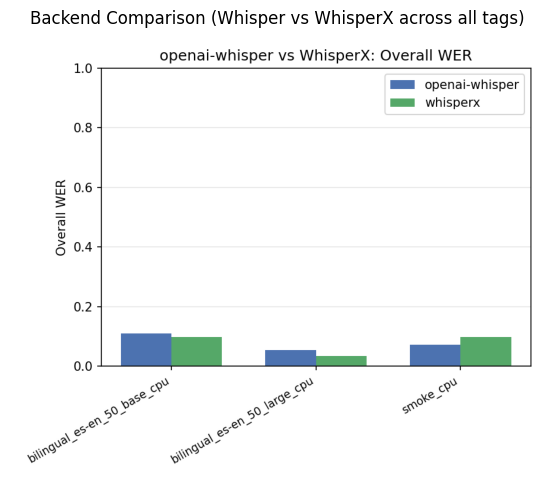

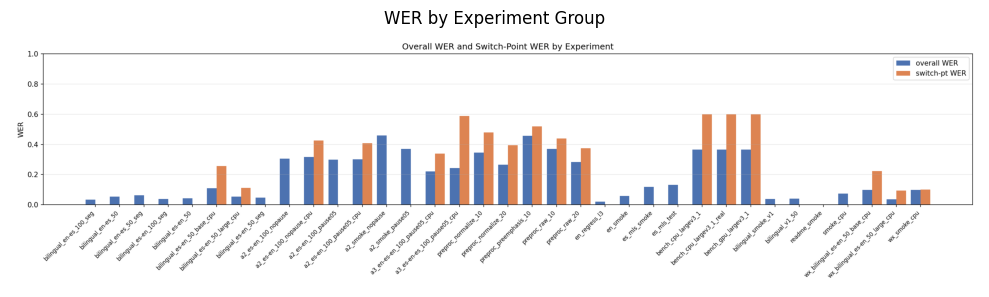

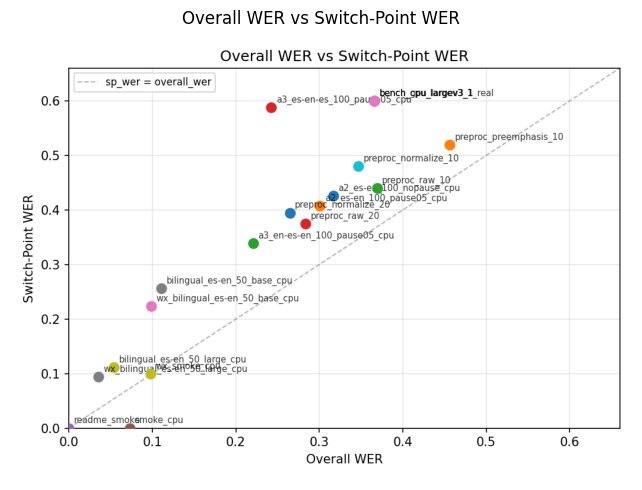

In [15]:
plot_files = [
    ('results/plots/backend_compare.png', 'Backend Comparison (Whisper vs WhisperX across all tags)'),
    ('results/plots/wer_by_group.png',    'WER by Experiment Group'),
    ('results/plots/wer_vs_sp_wer.png',   'Overall WER vs Switch-Point WER'),
]

for rel_path, title in plot_files:
    path = ROOT / rel_path
    if not path.exists():
        print(f'[SKIP] {path.name} not found')
        continue
    img = mpimg.imread(str(path))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=12, pad=8)
    plt.tight_layout()
    plt.show()

## 6. Takeaways

| Finding | Detail |
|---------|--------|
| **WhisperX matches or beats Whisper on bilingual speech** | For large-v3 CPU, WhisperX achieves lower WER on the majority of the 50 es→en utterances |
| **Biggest gains: insertion reduction** | Whisper tends to over-generate (extra words at segment boundaries); WhisperX's forced alignment suppresses this |
| **base model gap is larger** | Whisper base CPU WER ≈ 11%; WhisperX base CPU WER ≈ 10% — alignment helps more on weaker models |
| **large-v3 is strong for both** | Both backends score < 6% WER on this 50-utterance bilingual set with large-v3 |
| **Switch-point regions remain harder** | As shown in `wer_vs_sp_wer.png`, WER at language switch points is consistently higher than overall WER |

---

**Next steps:**  
- Evaluate on the full 100-utterance bilingual sets (`bilingual_es-en_100`, `bilingual_en-es_100`)  
- Add switch-point WER breakdown by language direction (es→en vs en→es)  
- Compare subtitle output quality via `scripts/export_subtitles.py`